# Project Overview

**Objective:** Build and evaluate a semantic segmentation model for detecting water bodies using multi-channel satellite data.

**Dataset:** Harmonized Sentinel-2/Landsat data. Features 12 spectral bands and data metrics per image. Optimized to use 4 selected bands based on physical properties and historical probability maps for stable water detection.

**Architecture:** Pretrained U-Net featuring a ResNet50 backbone (transferred from ImageNet via `segmentation_models_pytorch`).

**Training Strategy:** Binary Cross-Entropy (BCEWithLogitsLoss) using the Adam Optimizer, optimized further with Early Stopping and a ReduceLROnPlateau learning rate scheduler based on the validation data results.


# Imports & Setup

Import necessary libraries for deep learning, image processing, and data visualization.


In [1]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.6 MB/s eta 0:00:00


In [2]:
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import segmentation_models_pytorch as smp
import tifffile
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.v2 as transforms_v2


# Configuration

Define paths, image dimensions, batch size, and hyperparameters.


In [3]:
data_path = "/kaggle/input/datasets/mohamdhussein/water-segmentation/Data"
image_size = 224
batch_size = 8
epochs = 100

# Dataset Definition

Custom PyTorch Dataset class to read multispectral `.tif` images, select specific bands, and load binary water masks.


In [4]:
class waterDataset(Dataset):
    def __init__(self, images_list, masks_dir, images_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.images = images_list
        self.transform = transform

    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_name = self.images[idx]
        base_name = img_name.replace('.tif', '')
        mask_name = base_name + '.png'
        
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, mask_name)

        image = tifffile.imread(img_path).astype(np.float32)

        band_indices = [5, 7, 10, 11]
        image = image[:, :, band_indices]
        
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask not found at {mask_path}")
        mask = mask.astype(np.float32)
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].unsqueeze(0)
        else:
            image = np.transpose(image, (2, 0, 1))
            image = torch.from_numpy(image)
            mask = torch.from_numpy(mask).unsqueeze(0)
            
        return image, mask

# Data Loading & Augmentation

Split the data into training and validation sets, apply albumentations transforms, and initialize PyTorch DataLoaders.


In [5]:
images_dir = os.path.join(data_path, "images")
masks_dir = os.path.join(data_path, "labels")

all_images = [f for f in os.listdir(images_dir) if f.endswith('.tif')]
all_images.sort()

train_images, val_images = train_test_split(all_images, test_size=0.2, random_state=42)

train_transform = A.Compose([
    A.Resize(image_size, image_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Transpose(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(-0.0625, 0.0625), rotate=(-45, 45), shear=(-10, 10), p=0.5),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(image_size, image_size),
    ToTensorV2()
])

train_dataset = waterDataset(train_images, masks_dir, images_dir, transform=train_transform)
val_dataset = waterDataset(val_images, masks_dir, images_dir, transform=val_transform)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=os.cpu_count())
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=os.cpu_count())

print(f"Total items in train dataset: {len(train_dataset)}")
print(f"Number of train batches: {len(train_dataloader)}")
print(f"Total items in val dataset: {len(val_dataset)}")
print(f"Number of val batches: {len(val_dataloader)}")

Total items in train dataset: 244
Number of train batches: 31
Total items in val dataset: 62
Number of val batches: 8


# Data Visualization

Visualize a sample image, showing all available spectral bands, a false-color composite, and its corresponding ground truth mask.


Visualizing 12 bands, RGB, and Mask for image: 26.tif


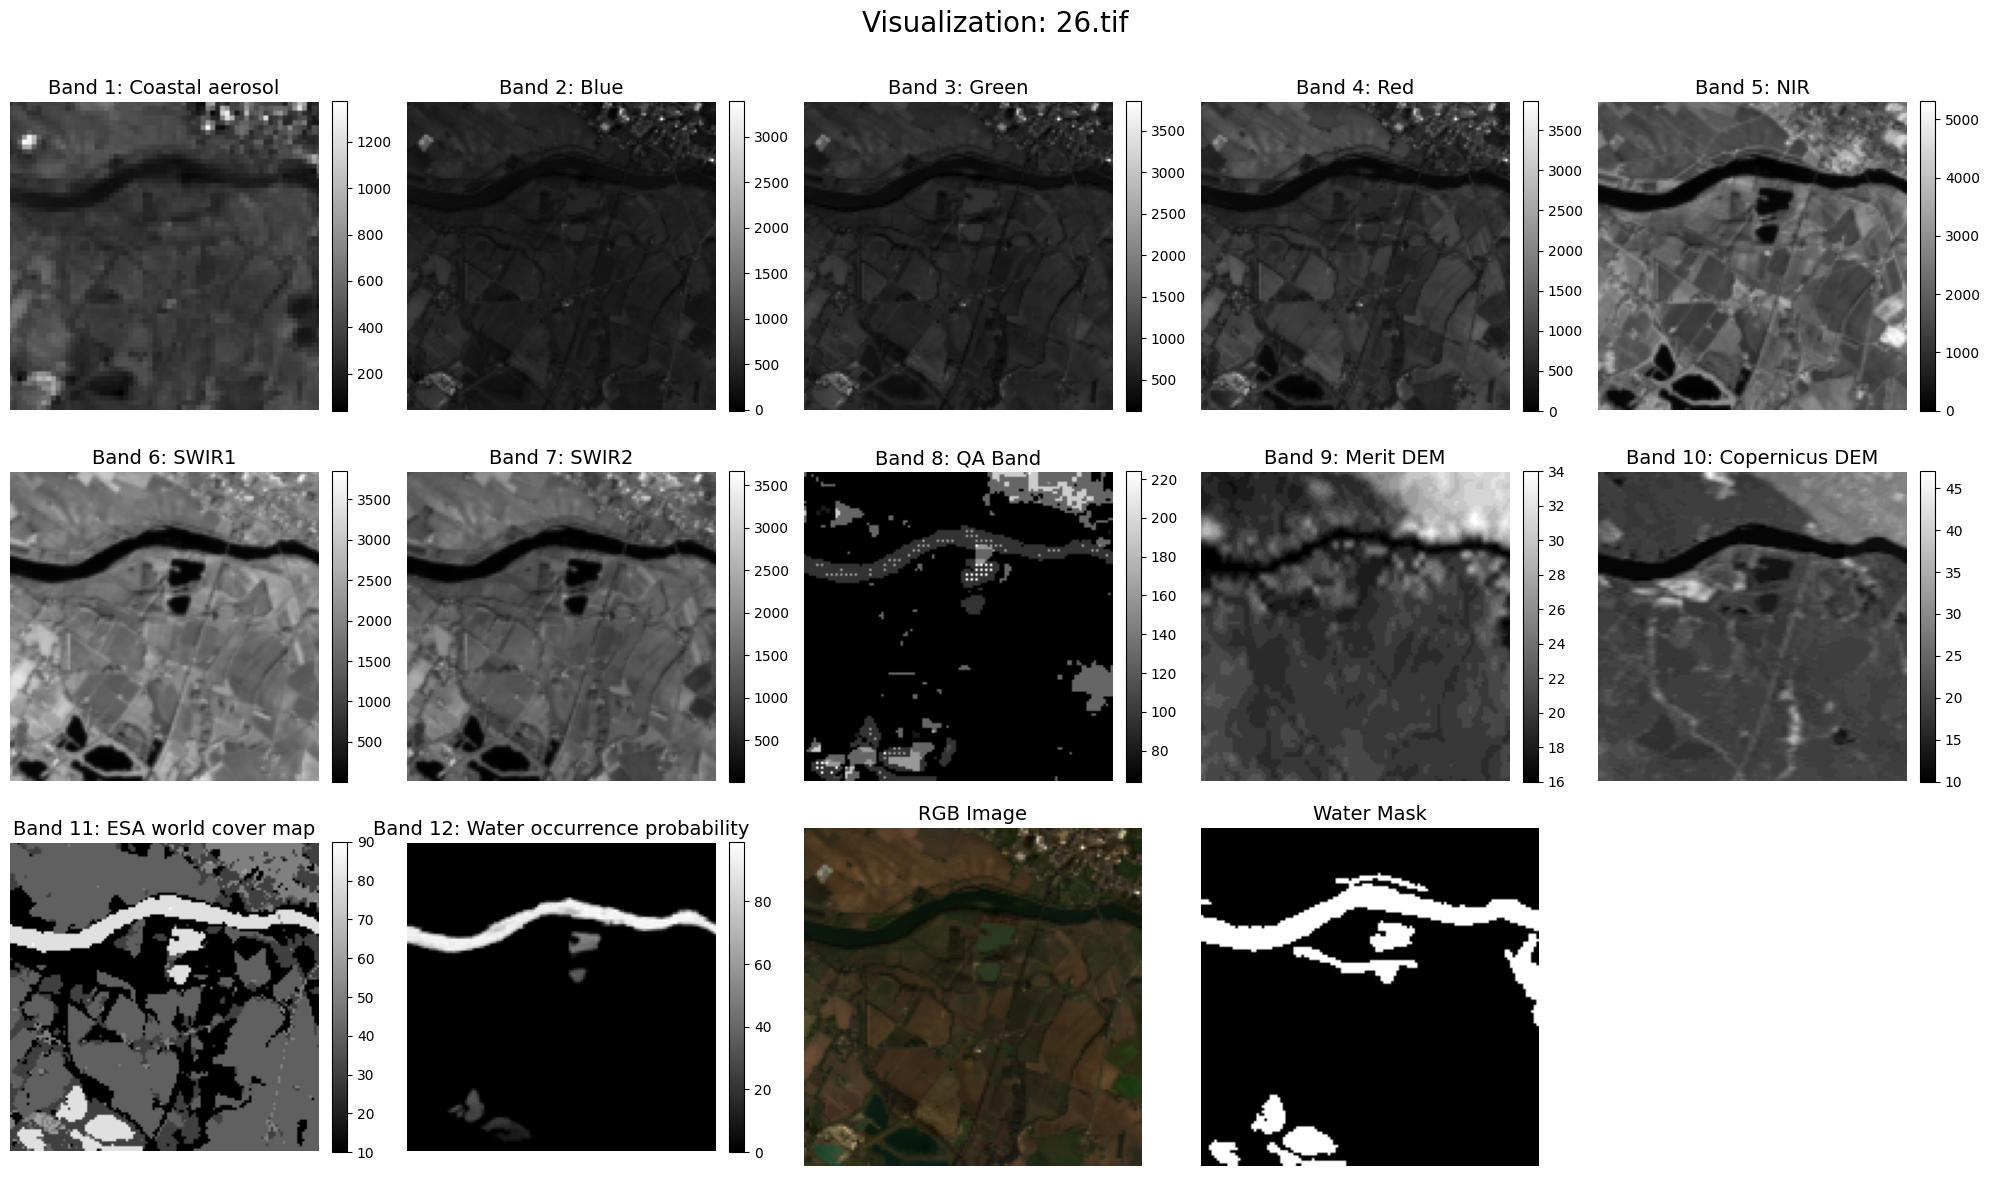

In [6]:
sample_image_name = train_images[3]
sample_image_path = os.path.join(images_dir, sample_image_name)
sample_mask_name = sample_image_name.replace('.tif', '.png')
sample_mask_path = os.path.join(masks_dir, sample_mask_name)

sample_image = tifffile.imread(sample_image_path)
num_bands = sample_image.shape[-1]

sample_mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

print(f"Visualizing {num_bands} bands, RGB, and Mask for image: {sample_image_name}")

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle(f"Visualization: {sample_image_name}", fontsize=20)

band_names = ["Coastal aerosol", "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2", "QA Band", "Merit DEM", "Copernicus DEM", "ESA world cover map", "Water occurrence probability"]
for i in range(12):
    ax = axes.flat[i]
    if i < num_bands:
        band_data = sample_image[:, :, i]
        im = ax.imshow(band_data, cmap='gray')
        ax.set_title(f"Band {i+1}: {band_names[i]}", fontsize=14)
        ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax_rgb = axes.flat[12]
rgb_img = sample_image[:, :, [3, 2, 1]].astype(np.float32)
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-8)
ax_rgb.imshow(rgb_img)
ax_rgb.set_title("RGB Image", fontsize=14)
ax_rgb.axis('off')

ax_mask = axes.flat[13]
im_mask = ax_mask.imshow(sample_mask, cmap='gray')
ax_mask.set_title("Water Mask", fontsize=14)
ax_mask.axis('off')

axes.flat[14].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


# Pretrained UNet Architecture

Define the U-Net model using the `segmentation_models_pytorch` library. It initializes a U-Net architecture with a ResNet50 backbone loaded with official ImageNet weights. The input convolution layer automatically adapts to accept 4 channels while retaining weights where possible.

In [7]:
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=4,
    classes=1,
)

model = model.to(device)

dummy_input = torch.randn(8, 4, 512, 512).to(device)
dummy_output = model(dummy_input)

print(f"Model Input shape: {dummy_input.shape}")
print(f"Model Output shape: {dummy_output.shape} (Expected: [8, 1, 512, 512])")


Using device: cuda


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Model Input shape: torch.Size([8, 4, 512, 512])
Model Output shape: torch.Size([8, 1, 512, 512]) (Expected: [8, 1, 512, 512])


# Training Loop

Define the loss function (`BCEWithLogitsLoss` for binary segmentation without a trailing sigmoid), the optimizer (`Adam`), and run the training iterations over the dataset.

In [8]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses = []
val_losses = []

print("Starting Training...")
for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_train_loss = 0.0
    
    for batch_idx, (images, masks) in enumerate(train_dataloader):
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
    avg_train_loss = running_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    
    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for images, masks in val_dataloader:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            running_val_loss += loss.item()
            
    avg_val_loss = running_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)
    
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch [{epoch+1}/{epochs}] | LR: {current_lr:.1e} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    scheduler.step(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_unet_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            break

print("Training Complete!")


Starting Training...
Epoch [1/100] | LR: 1.0e-04 | Train Loss: 0.5032 | Val Loss: 0.3713
Epoch [2/100] | LR: 1.0e-04 | Train Loss: 0.3908 | Val Loss: 0.3526
Epoch [3/100] | LR: 1.0e-04 | Train Loss: 0.3548 | Val Loss: 0.2729
Epoch [4/100] | LR: 1.0e-04 | Train Loss: 0.3361 | Val Loss: 0.2833
Epoch [5/100] | LR: 1.0e-04 | Train Loss: 0.3130 | Val Loss: 0.2411
Epoch [6/100] | LR: 1.0e-04 | Train Loss: 0.2995 | Val Loss: 0.2289
Epoch [7/100] | LR: 1.0e-04 | Train Loss: 0.2748 | Val Loss: 0.2147
Epoch [8/100] | LR: 1.0e-04 | Train Loss: 0.2842 | Val Loss: 0.2117
Epoch [9/100] | LR: 1.0e-04 | Train Loss: 0.2574 | Val Loss: 0.1939
Epoch [10/100] | LR: 1.0e-04 | Train Loss: 0.2573 | Val Loss: 0.2012
Epoch [11/100] | LR: 1.0e-04 | Train Loss: 0.2560 | Val Loss: 0.2150
Epoch [12/100] | LR: 1.0e-04 | Train Loss: 0.2494 | Val Loss: 0.1985
Epoch [13/100] | LR: 1.0e-04 | Train Loss: 0.2400 | Val Loss: 0.1934
Epoch [14/100] | LR: 1.0e-04 | Train Loss: 0.2311 | Val Loss: 0.1955
Epoch [15/100] | LR: 1

# Evaluation Metrics

Define functions to calculate IoU, Precision, Recall, and F1-score to evaluate the model's segmentation performance.

In [9]:
def calculate_metrics(preds, targets, threshold=0.5):
    preds = torch.sigmoid(preds)
    
    preds = (preds > threshold).long()
    targets = targets.long()
    
    TP = (preds * targets).sum().float()
    FP = ((preds == 1) & (targets == 0)).sum().float()
    FN = ((preds == 0) & (targets == 1)).sum().float()
    
    smooth = 1e-6
    
    iou = (TP + smooth) / (TP + FP + FN + smooth)
    precision = (TP + smooth) / (TP + FP + smooth)
    recall = (TP + smooth) / (TP + FN + smooth)
    f1_score = (2 * precision * recall) / (precision + recall + smooth)
    
    return iou.item(), precision.item(), recall.item(), f1_score.item()

print("Metrics functions defined.")


Metrics functions defined.


# Plotting Learning Curves & Final Evaluation

Plot the Training vs Validation Loss over the epochs, and run the model across the entire validation DataLoader to calculate the final IoU, Precision, Recall, and F1-score.

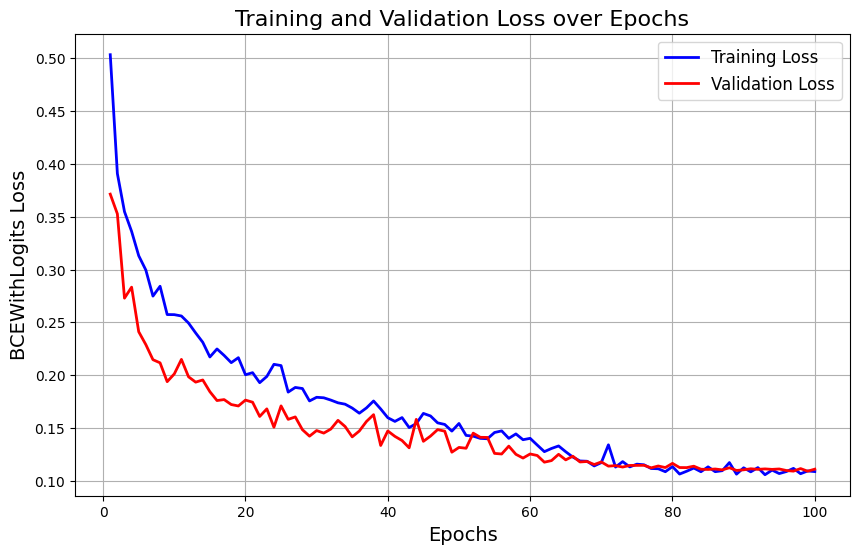

Starting Final Evaluation on Validation Set...
----------------------------------------
FINAL VALIDATION METRICS
----------------------------------------
Mean IoU:       0.8008
Mean Precision: 0.9053
Mean Recall:    0.8726
Mean F1-Score:  0.8865
----------------------------------------


In [10]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='red', linewidth=2)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('BCEWithLogits Loss', fontsize=14)
plt.title('Training and Validation Loss over Epochs', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# ---------------------------------------------
# ---------------------------------------------
print("Starting Final Evaluation on Validation Set...")
model.eval()

total_iou = 0.0
total_precision = 0.0
total_recall = 0.0
total_f1 = 0.0

with torch.no_grad():
    for images, masks in val_dataloader:
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        
        iou, precision, recall, f1 = calculate_metrics(outputs, masks)
        
        total_iou += iou
        total_precision += precision
        total_recall += recall
        total_f1 += f1

num_batches = len(val_dataloader)
avg_iou = total_iou / num_batches
avg_precision = total_precision / num_batches
avg_recall = total_recall / num_batches
avg_f1 = total_f1 / num_batches

print("-" * 40)
print("FINAL VALIDATION METRICS")
print("-" * 40)
print(f"Mean IoU:       {avg_iou:.4f}")
print(f"Mean Precision: {avg_precision:.4f}")
print(f"Mean Recall:    {avg_recall:.4f}")
print(f"Mean F1-Score:  {avg_f1:.4f}")
print("-" * 40)
